# 01 — Rate decomposition: Kitagawa, Das Gupta, and replacement

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Derive the two-factor rate decomposition.
- Recognize path dependence with three or more factors.
- Implement stepwise, Das Gupta, and Shorrocks all-orders allocations.
- Interpret Chevan–Sutherland category-level refinements.
- Handle entrant/exit segments and compare direct with chained multiperiod decompositions.

## Roadmap and notation

### Guiding question

When an aggregate conversion rate changes, how much is associated with a different mix of users and how much with different conversion rates inside the same segments?

### Prerequisites

Weighted averages and percentage-point changes. Notebook 00's distinction between contribution and causation is assumed.

### Symbols

| Symbol | Meaning |
|---|---|
| $g$ | segment, such as channel or customer type |
| $t\in\{0,1\}$ | baseline and comparison periods |
| $w_{gt}$ | share of observations in segment $g$; $\sum_gw_{gt}=1$ |
| $r_{gt}$ | rate inside segment $g$ |
| $R_t$ | aggregate rate $\sum_gw_{gt}r_{gt}$ |
| $C_w,C_r$ | mix and within-segment-rate contributions |

The central route is Kitagawa $\rightarrow$ Das Gupta $\rightarrow$ Chevan–Sutherland: from two blocks, to multiple compositional variables, to categories nested inside those variables. Stepwise replacement then exposes the computational path problem, and Shorrocks supplies a general axiomatic rule. The notebook closes with missing segment rates and multiperiod chaining.

## Kitagawa identity: intuition

For group $g$, the aggregate rate is $R_t=\sum_g w_{gt}r_{gt}$. Kitagawa's symmetric allocation is
$$C_w=\sum_g(w_{g1}-w_{g0})(r_{g1}+r_{g0})/2,$$
$$C_r=\sum_g(r_{g1}-r_{g0})(w_{g1}+w_{g0})/2.$$
Then $C_w+C_r=R_1-R_0$ exactly. These are composition and within-group-rate components—not causal effects. Das Gupta generalized standardization to several factors. Stepwise replacement is exact but generally order-dependent; averaging all orders produces a Shapley-style symmetric allocation.

## Kitagawa: derivation and proof of exactness

We want to decompose the change in the aggregate rate

$$R_t=\sum_{g=1}^{G}w_{gt}r_{gt},\qquad \sum_{g=1}^{G}w_{gt}=1.$$

Define $\Delta w_g=w_{g1}-w_{g0}$ and $\Delta r_g=r_{g1}-r_{g0}$. For one segment,

$$w_{g1}r_{g1}-w_{g0}r_{g0}
=(w_{g0}+\Delta w_g)(r_{g0}+\Delta r_g)-w_{g0}r_{g0}.$$

Expanding the product gives

$$w_{g1}r_{g1}-w_{g0}r_{g0}
=r_{g0}\Delta w_g+w_{g0}\Delta r_g+\Delta w_g\Delta r_g.$$

The first term is a pure mix change evaluated at the baseline rate; the second is a pure rate change evaluated at the baseline share; the third is an interaction because both quantities changed. Kitagawa allocates half of that interaction to each component:

$$C_{w,g}=r_{g0}\Delta w_g+\frac12\Delta w_g\Delta r_g
=\Delta w_g\frac{r_{g0}+r_{g1}}{2},$$

$$C_{r,g}=w_{g0}\Delta r_g+\frac12\Delta w_g\Delta r_g
=\Delta r_g\frac{w_{g0}+w_{g1}}{2}.$$

Adding the two components for one segment recovers its exact observed change:

$$C_{w,g}+C_{r,g}
=r_{g0}\Delta w_g+w_{g0}\Delta r_g+\Delta w_g\Delta r_g
=w_{g1}r_{g1}-w_{g0}r_{g0}.$$

Finally, summing over all segments proves the aggregate identity:

$$\boxed{R_1-R_0=\sum_g C_{w,g}+\sum_g C_{r,g}}.$$

The 50/50 interaction split makes the decomposition symmetric under reversal of periods. It is a defensible convention, not a uniquely identified scientific effect.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

In [2]:
# One row per stable customer segment; shares sum to one in each period.
d = pd.DataFrame({
    'segment': ['New', 'Returning', 'Enterprise'],
    'w0': [.50, .35, .15],
    'w1': [.42, .38, .20],
    'r0': [.08, .18, .31],
    'r1': [.10, .17, .34],
})

# Kitagawa's symmetric mix and rate contributions, calculated by segment.
d['mix'] = (d.w1 - d.w0) * (d.r1 + d.r0) / 2
d['rate'] = (d.r1 - d.r0) * (d.w1 + d.w0) / 2

R0 = (d.w0 * d.r0).sum()
R1 = (d.w1 * d.r1).sum()
summary = pd.Series({
    'R0': R0,
    'R1': R1,
    'change': R1 - R0,
    'mix': d['mix'].sum(),
    'rate': d['rate'].sum(),
    'error': (R1 - R0) - d[['mix', 'rate']].to_numpy().sum(),
})
d, summary

(      segment     w0     w1     r0     r1     mix    rate
 0         New 0.5000 0.4200 0.0800 0.1000 -0.0072  0.0092
 1   Returning 0.3500 0.3800 0.1800 0.1700  0.0053 -0.0036
 2  Enterprise 0.1500 0.2000 0.3100 0.3400  0.0163  0.0053,
 R0        0.1495
 R1        0.1746
 change    0.0251
 mix       0.0143
 rate      0.0108
 error    -0.0000
 dtype: float64)

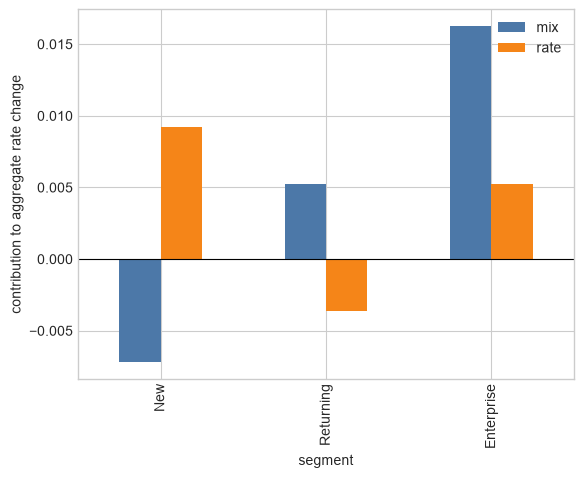

In [3]:
segment_contributions = d.set_index('segment')[['mix', 'rate']]
ax = segment_contributions.plot.bar(color=['#4C78A8', '#F58518'])
ax.axhline(0, color='black', linewidth=.8)
ax.set_ylabel('contribution to aggregate rate change')
plt.show()

## Reading the worked example

The aggregate rate rises from 0.1495 to 0.1746, a change of **0.0251**, or **2.51 percentage points**. The method allocates 1.43 pp to mix and 1.08 pp to within-segment rates. The near-zero `error` verifies the identity numerically.

At segment level, New users contribute negatively through mix because their traffic share falls, but positively through rate because their CVR improves. Enterprise contributes positively through both channels. Positive does not mean “good intervention”; it means positive contribution to the observed aggregate change under this rule.

## Growth-marketing case: conversion rate

Let $w_{gt}$ be the traffic share of channel $g$ and $r_{gt}$ its conversion rate. Then total CVR is $R_t=\sum_g w_{gt}r_{gt}$.

- **Mix contribution:** traffic moved toward channels with higher/lower CVR.
- **Rate contribution:** within-channel CVR changed.
- **Actionable diagnostic:** split further by device, geography, landing page, or cohort, but check sparse cells and post-treatment segmentation.

Example claim for the worked data: “Total CVR rose 2.51 pp; under the Kitagawa two-period rule, +1.43 pp is allocated to segment mix and +1.08 pp to within-segment rates.” This is precise and descriptive. “The new campaign caused +1.08 pp” is not supported without an experiment or credible quasi-experiment.

In [4]:
# Aggregation check: collapse Returning and Enterprise.
# The collapsed rate must be share-weighted separately in each period.
fine = d.copy()
collapsed = pd.DataFrame({
    'segment': ['New', 'Established'],
    'w0': [fine.loc[0, 'w0'], fine.loc[1:, 'w0'].sum()],
    'w1': [fine.loc[0, 'w1'], fine.loc[1:, 'w1'].sum()],
    'r0': [fine.loc[0, 'r0'],
           np.average(fine.loc[1:, 'r0'], weights=fine.loc[1:, 'w0'])],
    'r1': [fine.loc[0, 'r1'],
           np.average(fine.loc[1:, 'r1'], weights=fine.loc[1:, 'w1'])],
})
collapsed['mix'] = (collapsed.w1-collapsed.w0)*(collapsed.r1+collapsed.r0)/2
collapsed['rate'] = (collapsed.r1-collapsed.r0)*(collapsed.w1+collapsed.w0)/2

comparison = pd.DataFrame({
    'fine segmentation': [R0, R1, R1-R0, d['mix'].sum(), d['rate'].sum()],
    'collapsed segmentation': [
        (collapsed.w0*collapsed.r0).sum(),
        (collapsed.w1*collapsed.r1).sum(),
        (collapsed.w1*collapsed.r1).sum()-(collapsed.w0*collapsed.r0).sum(),
        collapsed['mix'].sum(),
        collapsed['rate'].sum(),
    ],
}, index=['R0','R1','total change','mix','rate'])
comparison

,fine segmentation,collapsed segmentation
R0,0.1495,0.1495
R1,0.1746,0.1746
total change,0.0251,0.0251
mix,0.0143,0.0107
rate,0.0108,0.0144


## Is the result consistent when segments are aggregated?

There are two different consistency questions.

### 1. Is the aggregate rate preserved? Yes—if aggregation is done correctly

For a block $H$ containing several fine segments, define

$$w_{Ht}=\sum_{g\in H}w_{gt},\qquad
r_{Ht}=\frac{\sum_{g\in H}w_{gt}r_{gt}}{w_{Ht}}.$$

Then $w_{Ht}r_{Ht}=\sum_{g\in H}w_{gt}r_{gt}$. Therefore $R_0$, $R_1$, and $R_1-R_0$ are exactly unchanged after collapsing segments. A simple unweighted average of rates would fail this property.

### 2. Are the mix and rate components preserved? Generally no

The fine decomposition evaluates every $\Delta w_g$ against its own average rate. The collapsed decomposition first creates a changing within-block weighted rate $r_{Ht}$ and then treats that block as one segment. Variation in shares **inside** $H$ is no longer visible as mix; part of it is absorbed into the block's rate component. Thus the total remains exact, while the labels `mix` and `rate` are reallocated.

This is not a coding inconsistency. It is a lack of **aggregation invariance**. The decomposition answers a question conditional on the chosen partition. Report the segmentation rule and repeat the analysis at substantively plausible levels.

## The methodological route: Kitagawa $\rightarrow$ Das Gupta $\rightarrow$ Chevan–Sutherland

These are not three unrelated estimators. They form a progressively finer route through the same accounting problem.

| Stage | Question answered | Exact output | Limitation that motivates the next stage |
|---|---|---|---|
| **Kitagawa (1955)** | Did an aggregate rate change because group shares changed or because rates changed within groups? | one composition effect plus one rate effect | with several compositional variables, treating their cross-products as separate interactions becomes unwieldy |
| **Das Gupta (1978, 1993)** | How much is associated with each of several cross-classified compositional variables? | one composition effect per variable plus one overall rate effect | a variable total such as “channel” does not reveal which channel categories matter |
| **Chevan–Sutherland (2009)** | Which categories inside each Das Gupta variable produce its composition and rate contributions? | additive category effects nested inside the variable effects | the result remains descriptive and can be unstable in sparse or substantively arbitrary partitions |

### Stage 1 — Kitagawa: the two-block identity

For a single grouping variable, Kitagawa writes

$$
\Delta R=C_W^{K}+C_R^{K}.
$$

$C_W^{K}$ changes the observed composition while standardizing rates symmetrically; $C_R^{K}$ changes the within-group rates while standardizing composition symmetrically. This answers **mix versus within-segment performance**, but it treats the segmentation as one joint partition.

### Stage 2 — Das Gupta: several compositional variables

Let $v=1,\ldots,V$ index variables such as channel, device, region, and tenure. Das Gupta constructs coherent standardized rates and distributes cross-variable interaction terms symmetrically, yielding

$$
\boxed{\Delta R=C_R^{DG}+\sum_{v=1}^{V}C_v^{DG}}.
$$

Each $C_v^{DG}$ is the composition effect of a variable, while $C_R^{DG}$ is the overall change in cell-specific rates. The standardized hybrids specify what changes and what remains fixed; exactness alone does not determine that choice.

### Stage 3 — Chevan–Sutherland: categories nested inside variables

If $\mathcal K_v$ is the category set of variable $v$, Chevan–Sutherland refine each parent composition effect:

$$
C_v^{DG}=\sum_{k\in\mathcal K_v}C_{v,k}^{CS}.
$$

They also allocate the overall rate effect across the $V$ variable families and their categories:

$$
C_R^{DG}=\sum_{v=1}^{V}\sum_{k\in\mathcal K_v}C_{R,vk}^{CS},
$$

using a $1/V$ scaling in each variable family so that the same overall rate effect is not counted $V$ times. Define the total effect reported for category $k$ of variable $v$ as

$$
CE_{v,k}=C_{v,k}^{CS}+C_{R,vk}^{CS}.
$$

The nested conservation identity is therefore

$$
\boxed{\Delta R=\sum_{v=1}^{V}\sum_{k\in\mathcal K_v}CE_{v,k}}.
$$

This is a **secondary decomposition**: Chevan–Sutherland do not replace Das Gupta; they open each Das Gupta parent effect and show its category-level anatomy. Nor should one add separate one-way Kitagawa decompositions for channel, device, and region: each would reproduce the total contrast and the sum would double- or triple-count it.

### Growth interpretation

- **Kitagawa:** how much of the CVR change is joint segment mix versus within-joint-segment CVR?
- **Das Gupta:** how much is channel composition, device composition, region composition, and the overall cell-rate effect?
- **Chevan–Sutherland:** inside those parents, were Paid Search or Organic, Mobile or Desktop, and particular regions positive or negative contributors?

Stepwise replacement, introduced next, is the computational bridge that makes hybrid states and order dependence visible. It is not a fourth substantive endpoint in this historical route.

## Stepwise Replacement: the bridge from Kitagawa to Das Gupta

Kitagawa has only two changing objects—shares and rates—and resolves their interaction by splitting it equally. When a function contains three or more changing factors, a simple alternative is to replace them **one at a time**.

Let

$$Y_t=F(x_{1t},x_{2t},\ldots,x_{Kt}).$$

Choose one order, for example $x_1\rightarrow x_2\rightarrow\cdots\rightarrow x_K$. Define hybrid states

$$z^{(0)}=(x_{10},x_{20},\ldots,x_{K0}),$$

$$z^{(1)}=(x_{11},x_{20},\ldots,x_{K0}),$$

$$z^{(2)}=(x_{11},x_{21},\ldots,x_{K0}),$$

and continue until $z^{(K)}=(x_{11},\ldots,x_{K1})$. The contribution assigned at step $j$ is

$$C_j^{(\pi)}=F\!\left(z^{(j)}\right)-F\!\left(z^{(j-1)}\right),$$

where $\pi$ denotes the selected order. Adding all steps produces a telescoping sum:

$$\sum_{j=1}^{K}C_j^{(\pi)}
=[F(z^{(1)})-F(z^{(0)})]
+[F(z^{(2)})-F(z^{(1)})]+\cdots
+[F(z^{(K)})-F(z^{(K-1)})].$$

Every intermediate value appears once with a positive sign and once with a negative sign, so the sum telescopes:

so

$$\boxed{\sum_j C_j^{(\pi)}=Y_1-Y_0}.$$

Thus every stepwise path is **exact**. But when factors interact, the individual $C_j^{(\pi)}$ depend on the order $\pi$, because a factor replaced later operates on a different hybrid state.

In [5]:
# One exact stepwise decomposition for Revenue = Traffic × CVR × AOV.
stepwise_base = {'traffic': 1_000., 'cvr': .04, 'aov': 50.}
stepwise_final = {'traffic': 1_200., 'cvr': .05, 'aov': 48.}

def revenue_identity(values):
    return values['traffic'] * values['cvr'] * values['aov']

def stepwise_decomposition(base_values, final_values, order):
    # Replace factors in `order` and return their successive increments.
    state = base_values.copy()
    rows = []
    for factor in order:
        before = revenue_identity(state)
        state[factor] = final_values[factor]
        after = revenue_identity(state)
        rows.append({
            'factor replaced': factor,
            'value before': before,
            'value after': after,
            'contribution': after - before,
        })
    return pd.DataFrame(rows)

order_a = ['traffic', 'cvr', 'aov']
order_b = ['aov', 'cvr', 'traffic']
path_a = stepwise_decomposition(stepwise_base, stepwise_final, order_a)
path_b = stepwise_decomposition(stepwise_base, stepwise_final, order_b)

order_comparison = pd.DataFrame({
    'Traffic → CVR → AOV': path_a.set_index('factor replaced')['contribution'],
    'AOV → CVR → Traffic': path_b.set_index('factor replaced')['contribution'],
}).reindex(['traffic', 'cvr', 'aov'])

path_a, order_comparison, order_comparison.sum().rename('total change')

(  factor replaced  value before  value after  contribution
 0         traffic    2,000.0000   2,400.0000      400.0000
 1             cvr    2,400.0000   3,000.0000      600.0000
 2             aov    3,000.0000   2,880.0000     -120.0000,
                  Traffic → CVR → AOV  AOV → CVR → Traffic
 factor replaced                                          
 traffic                     400.0000             480.0000
 cvr                         600.0000             480.0000
 aov                        -120.0000             -80.0000,
 Traffic → CVR → AOV   880.0000
 AOV → CVR → Traffic   880.0000
 Name: total change, dtype: float64)

## Reading the Stepwise output

For the order Traffic → CVR → AOV, the contributions are 400, 600, and −120. For the reverse-style order AOV → CVR → Traffic, they are 480, 480, and −80. Both columns sum to the same observed revenue change, 880.

The difference is entirely due to interactions. For example, the traffic increase is worth 400 when evaluated at baseline CVR and AOV, but 480 when evaluated after CVR and AOV have already changed. Neither order is algebraically wrong; the problem is that an arbitrary order gives an arbitrary interaction allocation.

This motivates Das Gupta's symmetric construction: calculate the stepwise marginal contribution along every possible order and average them.

## Das Gupta: from two factors to many factors

Kitagawa treats two changing objects: shares and rates. **Das Gupta (1978)** developed standardization and decomposition for a rate or function depending on several factors.

Let

$$F_t=F(x_{1t},x_{2t},\ldots,x_{Kt})$$

and consider a replacement order $\pi$. Start with all factors at period 0. Replace them one at a time with period-1 values. The marginal contribution of factor $j$ along order $\pi$ is

$$M_j^{(\pi)}=F\!\left(x^{(\pi,j,+)}\right)
-F\!\left(x^{(\pi,j,-)}\right),$$

where $x^{(\pi,j,-)}$ is the hybrid state immediately before replacing $j$ and $x^{(\pi,j,+)}$ is the state immediately after. Every path telescopes:

$$\sum_{j=1}^{K}M_j^{(\pi)}=F_1-F_0.$$

A symmetric contribution averages over all $K!$ orders:

$$C_j=\frac{1}{K!}\sum_{\pi}M_j^{(\pi)},\qquad
\sum_j C_j=F_1-F_0.$$

This averaging removes order dependence and distributes all higher-order interactions. In modern terminology it is closely connected to a Shapley–Shorrocks allocation. Das Gupta's demographic framework also uses standardized rates to isolate factors while preserving the marginal structures relevant to the application.

### What “multidimensional” means for an aggregate rate

Suppose conversion is cross-classified by channel $i$ and device $j$. A useful sequential factorization is

$$R_t=\sum_i p_{it}\sum_j q_{j\mid i,t}r_{ijt},$$

where $p_{it}=P_t(\text{channel}=i)$ and $q_{j\mid i,t}=P_t(\text{device}=j\mid\text{channel}=i)$. There are now three changing blocks:

1. $P$: channel composition $p$;
2. $Q$: device-within-channel composition $q$;
3. $R$: cell-specific conversion rates $r$.

Define the hybrid standardized rate

$$H(a,b,c)=\sum_i p_{i,a}\sum_j q_{j\mid i,b}r_{ij,c},\qquad a,b,c\in\{0,1\}.$$

Every $H(a,b,c)$ is a coherent synthetic population: $p_{\cdot,a}$ sums to one and every conditional distribution $q_{\cdot\mid i,b}$ sums to one. The channel contribution, averaged over the six paths, can equivalently be written with subset weights:

$$\begin{aligned}
C_P={}&\frac13[H(1,0,0)-H(0,0,0)]\\
&+\frac16[H(1,1,0)-H(0,1,0)]\\
&+\frac16[H(1,0,1)-H(0,0,1)]\\
&+\frac13[H(1,1,1)-H(0,1,1)].
\end{aligned}$$

$C_Q$ and $C_R$ follow by rotating the factor being replaced. The weights $1/3,1/6,1/6,1/3$ are the probabilities that zero, either one, or both of the other factors precede the target factor in a random order. Consequently,

$$C_P+C_Q+C_R=H(1,1,1)-H(0,0,0).$$

### The factorization is part of the estimand

Writing $P(\text{channel})P(\text{device}\mid\text{channel})$ asks a different descriptive question from writing $P(\text{device})P(\text{channel}\mid\text{device})$. Both reproduce the observed joint distributions at the endpoints, but their intermediate standardized populations differ. Therefore the separate channel and device allocations need not agree. This is not an algebraic error: it is sensitivity to the declared standardization structure.

If the joint cell shares $w_{ijt}$ are treated as one indivisible block, the analysis has only two factors—joint composition and cell rates—and cannot separately identify a channel-composition and device-composition component. Conversely, independently combining channel and device marginals implicitly assumes away their association and can create unrealistic hybrid cells.

### Closed form for a multiplicative business identity

For $F(x)=\prod_{k=1}^K x_k$, write $x_{k1}=x_{k0}+\Delta x_k$. Expansion gives one term for every nonempty interaction set $S$:

$$F_1-F_0=\sum_{\varnothing\neq S\subseteq K}
\left(\prod_{j\in S}\Delta x_j\right)
\left(\prod_{\ell\notin S}x_{\ell0}\right).$$

All-orders averaging allocates each $|S|$-way interaction equally among its participating factors. Hence

$$C_j=\sum_{S\ni j}\frac{1}{|S|}
\left(\prod_{k\in S}\Delta x_k\right)
\left(\prod_{\ell\notin S}x_{\ell0}\right).$$

For a growth identity such as revenue $=\text{traffic}\times\text{CVR}\times\text{AOV}$, this formula makes explicit where the pairwise and three-way interactions go. For a nonlinear or cross-classified rate, enumeration through $H$ is safer than trying to invent a product shortcut.

In [6]:
# Das Gupta / all-orders replacement for a 3-factor growth funnel.
# Revenue per impression = CTR × post-click CVR × AOV.
from math import factorial

factor_names = ['ctr', 'post_click_cvr', 'aov']
period0 = {'ctr': .020, 'post_click_cvr': .040, 'aov': 55.}
period1 = {'ctr': .023, 'post_click_cvr': .037, 'aov': 58.}

def funnel_value(values):
    return values['ctr'] * values['post_click_cvr'] * values['aov']

contributions = {name: 0.0 for name in factor_names}
path_rows = []
orders = list(permutations(factor_names))

for order in orders:
    state = period0.copy()
    path_contributions = {}
    for name in order:
        before = funnel_value(state)
        state[name] = period1[name]
        after = funnel_value(state)
        marginal = after - before
        contributions[name] += marginal / len(orders)
        path_contributions[name] = marginal
    path_rows.append({'order': ' → '.join(order), **path_contributions})

das_gupta_summary = pd.Series({
    **contributions,
    'allocated': sum(contributions.values()),
    'observed': funnel_value(period1) - funnel_value(period0),
})
pd.DataFrame(path_rows), das_gupta_summary

(                        order    ctr  post_click_cvr    aov
 0  ctr → post_click_cvr → aov 0.0066         -0.0038 0.0026
 1  ctr → aov → post_click_cvr 0.0066         -0.0040 0.0028
 2  post_click_cvr → ctr → aov 0.0061         -0.0033 0.0026
 3  post_click_cvr → aov → ctr 0.0064         -0.0033 0.0022
 4  aov → ctr → post_click_cvr 0.0070         -0.0040 0.0024
 5  aov → post_click_cvr → ctr 0.0064         -0.0035 0.0024,
 ctr               0.0065
 post_click_cvr   -0.0036
 aov               0.0025
 allocated         0.0054
 observed          0.0054
 dtype: float64)

## Reading the Das Gupta output

The first table shows that the marginal assigned to a factor changes with its replacement order; this is the interaction problem. The summary averages each factor's marginal across all six orders. `allocated` equals `observed`, so the symmetric multifactor decomposition is exact. The units are revenue per impression, because that is the function supplied to `funnel_value`.

Changing the function changes the scientific question. Multiplying by impressions would decompose total revenue; keeping revenue per impression deliberately removes traffic scale and focuses on funnel efficiency.

## Chevan & Sutherland (2009): categorical refinement of Das Gupta

### What problem did they solve?

Das Gupta's cross-classification framework decomposes a difference in aggregate rates into effects associated with compositional variables and an overall rate effect. In many applications, a variable-level result is too coarse. Knowing that “channel composition” matters does not reveal whether Search, Social, Email, or Affiliate generated the contribution.

Chevan and Sutherland make explicit a refinement already latent in the cross-classified framework: decompose both composition and rate effects down to the **categories** of each compositional variable. The categorical effects are additive:

$$C_w=\sum_g C_{w,g},\qquad C_r=\sum_g C_{r,g},$$

and therefore

$$R_1-R_0=\sum_g(C_{w,g}+C_{r,g}).$$

With one composition variable, these are exactly the segment-level Kitagawa contributions already calculated in the worked example. The contribution of Chevan–Sutherland is most valuable with several cross-classified variables, where effects can be reported both by variable and by category.

### Paper-faithful nested additivity

For two compositional variables $I$ and $J$, Chevan–Sutherland begin from the Das Gupta identity. Their paper writes the contrast as $t_{..}-T_{..}$; throughout this notebook we reverse the labels and use comparison minus baseline, $\Delta R=R_1-R_0$:

$$
\Delta R=C_R+C_I+C_J.
$$

They attach category subscripts to the standardized terms for each population so that the parent effects can be recovered exactly. Under this notebook's orientation,

$$
C_I=\sum_i\{I(A)_{i.}-I(a)_{i.}\},\qquad
C_J=\sum_j\{J(B)_{.j}-J(b)_{.j}\}.
$$

The overall rate effect is likewise reported through category families. With $V$ compositional variables, every family receives a $1/V$ share before it is divided among its categories. Hence

$$
C_R=\sum_i\{R(T)_{i.}-R(t)_{i.}\}
    +\sum_j\{R(T)_{.j}-R(t)_{.j}\}
$$

for $V=2$, where each family contains one half of the overall rate allocation. The paper first defines a category effect *inside each population*,

$$
CE^{(1)}_{i.}=I(A)_{i.}+R(T)_{i.},\qquad
CE^{(1)}_{.j}=J(B)_{.j}+R(T)_{.j},
$$

with analogous $CE^{(0)}$ terms for the baseline population. The contribution to the between-period contrast is their difference:

$$
C_{I,i}=CE^{(1)}_{i.}-CE^{(0)}_{i.},\qquad
C_{J,j}=CE^{(1)}_{.j}-CE^{(0)}_{.j}.
$$

Only these **differences** add to the contrast:

$$
\boxed{\Delta R=\sum_i C_{I,i}+\sum_j C_{J,j}}.
$$

This double hierarchy—within-population category effects, their between-population differences, and finally the crude-rate difference—is the central Chevan–Sutherland result.

The construction depends on Das Gupta's joint cross-classification and standardized composition coefficients. It is **not** obtained by running an independent Kitagawa decomposition for $I$ and another for $J$: both independent runs would allocate the full crude-rate difference and their sum would overcount it.

### Cross-classified interpretation

Suppose conversion is cross-classified by channel $i$ and device $j$:

$$R_t=\sum_i\sum_j w_{ijt}r_{ijt}.$$

A complete report can show:

- total composition and rate effects;
- channel-level category effects;
- device-level category effects;
- cell-level diagnostics that reveal offsetting contributions hidden by variable totals.

Category effects may be large and opposite in sign even when their variable-level total is small. This is analogous to the aggregation issue demonstrated earlier: cancellation at a coarse level can hide substantively important movements.

### Polytomous response variables

Chevan–Sutherland also extend the orientation from a binary/rate outcome to a response with categories $k=1,\ldots,K$, such as subscription status {free, trial, paid, churned}. For each composition cell $(i,j)$, define

$$t_{ijkt}=\frac{N_{ijkt}}{\sum_kN_{ijkt}},\qquad \sum_kt_{ijkt}=1.$$

These cell percentages replace the scalar rate in separate decompositions for each response category. The results distinguish:

- changes in the composition of users across channel/device cells;
- changes in the propensity to occupy each response category inside a cell.

Because response-category percentages sum to one, gains in some categories are balanced by losses in others. The paper further demonstrates extensions to the standard deviation and the multivariate index of dissimilarity.

### What the refinement does not solve

It does not make category effects causal, choose theoretically relevant control variables, solve sparse cross-classified cells, or guarantee aggregation invariance. Chevan and Sutherland explicitly emphasize that any selected categorical variable will yield a result; scientific meaning depends on theoretically justified variable selection.

### Applied templates for Chevan–Sutherland

| Decision problem | Composition dimensions | Response | What category detail can reveal |
|---|---|---|---|
| Paid-media CVR | channel × device | purchase/no purchase | Paid Search gained mix but mobile Search lost within-cell CVR |
| Lifecycle migration | acquisition cohort × tenure | free/trial/paid/churned | a larger young-cohort share versus worse paid retention inside mature cohorts |
| Subscription churn | country × plan | churn/no churn | churn pressure concentrated in a plan within one market rather than a global plan effect |
| Lead quality | source × firm size | MQL/SQL/won/lost | a source brings more volume while its distribution shifts toward low-quality states |
| Health or labor rates | age × sex or education × region | event rate or response categories | composition shifts separated from changes within comparable cells |

The operational sequence is: define the cross-classification before looking at results; construct coherent hybrid distributions; calculate variable-level Das Gupta effects; refine each replacement marginal into its categories; verify that categories sum to their parent factor and parent factors sum to $R_1-R_0$; then repeat under defensible alternative orderings, segment definitions, and sparse-cell rules.

### Exact two-variable Chevan–Sutherland implementation

Let $w_{ij,t}$ be the joint share of channel $I=i$ and device $J=j$. Das Gupta's symmetric composition coefficients factor every joint share as

$$
a_{ij}b_{ij}=w_{ij,0},\qquad A_{ij}B_{ij}=w_{ij,1},
$$

where

$$
a_{ij}=\sqrt{w_{ij,0}\frac{w_{i.,0}}{w_{.j,0}}},\qquad
b_{ij}=\sqrt{w_{ij,0}\frac{w_{.j,0}}{w_{i.,0}}},
$$

and $A,B$ are defined analogously for period 1. With bars denoting two-period arithmetic averages, the category composition contributions are

$$
C_{I,i}=\sum_j\bar r_{ij}\,\bar b_{ij}(A_{ij}-a_{ij}),\qquad
C_{J,j}=\sum_i\bar r_{ij}\,\bar a_{ij}(B_{ij}-b_{ij}).
$$

For $V=2$, category rate contributions are

$$
C_{R,I,i}=\frac12\sum_j\bar w_{ij}\Delta r_{ij},\qquad
C_{R,J,j}=\frac12\sum_i\bar w_{ij}\Delta r_{ij}.
$$

Each variable family receives one half of the rate effect; together they receive it exactly once. The code below implements these published equations and asserts all nesting identities.

In [7]:
# Exact Chevan–Sutherland refinement for channel × device (V = 2).
# q is device conditional on channel; p[:, None] * q gives joint shares.
channels = ['Paid Search', 'Organic']
devices = ['Mobile', 'Desktop']
p = [np.array([.55, .45]), np.array([.48, .52])]
q = [np.array([[.70, .30], [.60, .40]]),
     np.array([[.76, .24], [.64, .36]])]
r = [np.array([[.045, .080], [.035, .065]]),
     np.array([[.041, .086], [.040, .070]])]
w = [p[t][:, None] * q[t] for t in (0, 1)]

def das_gupta_coefficients(joint_share):
    # Symmetric a,b coefficients; their product reconstructs joint shares.
    row = joint_share.sum(axis=1)
    col = joint_share.sum(axis=0)
    if np.any(joint_share <= 0) or np.any(row <= 0) or np.any(col <= 0):
        raise ValueError('Original coefficients require positive joint and marginal shares.')
    coef_i = np.sqrt(joint_share * row[:, None] / col[None, :])
    coef_j = np.sqrt(joint_share * col[None, :] / row[:, None])
    np.testing.assert_allclose(coef_i * coef_j, joint_share)
    return coef_i, coef_j

a, b = das_gupta_coefficients(w[0])
A, B = das_gupta_coefficients(w[1])
r_bar = (r[0] + r[1]) / 2
w_bar = (w[0] + w[1]) / 2
a_bar, b_bar = (a + A) / 2, (b + B) / 2

composition_I = (r_bar * b_bar * (A - a)).sum(axis=1)
composition_J = (r_bar * a_bar * (B - b)).sum(axis=0)
rate_I = (w_bar * (r[1] - r[0]) / 2).sum(axis=1)  # 1 / V, V=2
rate_J = (w_bar * (r[1] - r[0]) / 2).sum(axis=0)

rows = []
rows += [('channel (I)', name, c, rr, c + rr)
         for name, c, rr in zip(channels, composition_I, rate_I)]
rows += [('device (J)', name, c, rr, c + rr)
         for name, c, rr in zip(devices, composition_J, rate_J)]
chevan_categories = pd.DataFrame(
    rows, columns=['variable family', 'category', 'composition', 'rate', 'total']
)

chevan_R0, chevan_R1 = np.sum(w[0] * r[0]), np.sum(w[1] * r[1])
parent_check = pd.Series({
    'I composition': composition_I.sum(),
    'J composition': composition_J.sum(),
    'overall rate': rate_I.sum() + rate_J.sum(),
})
identity_check = pd.Series({
    'baseline rate': chevan_R0,
    'comparison rate': chevan_R1,
    'observed change': chevan_R1 - chevan_R0,
    'allocated change': chevan_categories['total'].sum(),
})

np.testing.assert_allclose(rate_I.sum(), rate_J.sum())
np.testing.assert_allclose(parent_check.sum(), chevan_R1 - chevan_R0)
np.testing.assert_allclose(chevan_categories['total'].sum(), chevan_R1 - chevan_R0)

# Cross-check the pedagogical calculation against the production implementation.
from pathlib import Path
import sys
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from scripts.rate_decomposition import chevan_sutherland_two_variable
production_chevan = chevan_sutherland_two_variable(
    w[0], w[1], r[0], r[1], row_labels=channels, column_labels=devices
)
np.testing.assert_allclose(
    production_chevan.categories[['composition', 'rate', 'total']],
    chevan_categories[['composition', 'rate', 'total']],
)
chevan_categories, parent_check, identity_check

(  variable family     category  composition    rate   total
 0     channel (I)  Paid Search      -0.0041 -0.0003 -0.0045
 1     channel (I)      Organic       0.0036  0.0012  0.0048
 2      device (J)       Mobile       0.0019  0.0000  0.0019
 3      device (J)      Desktop      -0.0035  0.0009 -0.0026,
 I composition   -0.0005
 J composition   -0.0016
 overall rate     0.0018
 dtype: float64,
 baseline rate       0.0517
 comparison rate     0.0513
 observed change    -0.0004
 allocated change   -0.0004
 dtype: float64)

### How to read the two-dimensional result

The Paid Search and Organic rows partition the $I$ composition effect and one half of the overall rate effect. Mobile and Desktop partition the $J$ composition effect and the other half. `parent_check` recovers the Das Gupta parents, while `identity_check` verifies both parent-to-total and category-to-total conservation.

A negative Paid Search composition contribution does not say Paid Search caused conversion to fall. It says its standardized composition coefficients changed in a direction that lowers the aggregate rate under the Das Gupta rule. Likewise, a positive Mobile rate contribution can coexist with a negative Mobile composition contribution. This distinction is exactly why category-level reporting is useful.

For production use, report contributions in percentage points, include cell counts or effective sample sizes, flag cells created or removed between periods, and bootstrap the complete decomposition if sampling uncertainty matters. If a rate is undefined because a cell has zero exposure, use the explicit entrant/exit or reference-rate conventions discussed later; never silently replace the missing rate with zero.

In [8]:
# Chevan–Sutherland categorical reporting in the one-variable case.
# Segment contributions add to variable-level composition and rate effects.
category_report = d.set_index('segment')[['mix', 'rate']].copy()
category_report['total category contribution'] = category_report.sum(axis=1)
category_report.loc['variable-level total'] = category_report.sum(axis=0)
category_report.loc['observed aggregate change', 'total category contribution'] = R1-R0
category_report

,mix,rate,total category contribution
segment,,,
New,-0.0072,0.0092,0.0020
Returning,0.0053,-0.0036,0.0016
Enterprise,0.0163,0.0053,0.0215
variable-level total,0.0143,0.0108,0.0251
observed aggregate change,NaN,NaN,0.0251


### Reading the categorical report

The table exposes offsetting category effects. For example, the New segment has a negative mix effect but a positive rate effect. Reporting only the aggregate mix and rate totals would hide this internal structure.

The variable-level total is the sum of category rows, demonstrating Chevan–Sutherland additivity in this simplified case. With several composition variables, use cross-classified cells and aggregate category contributions carefully; do not compute separate one-way decompositions and add them, because that can double-count interactions.

## Shorrocks (2013): a unified Shapley decomposition

### General indicator and activation/neutralization game

Shorrocks begins with an indicator completely determined by $m$ factors:

$$I=f(X_1,X_2,\ldots,X_m).$$

Define $K=\{1,\ldots,m\}$ and use one consistent convention for the set function $F(S)$: factors in $S$ are active at their target values, while factors outside $S$ are placed at declared neutral or baseline values. Thus $F(\varnothing)$ is fully neutralized and $F(K)$ is the complete target indicator. The scientific content lies partly in that rule: neutralizing growth might mean setting a growth factor to zero, while neutralizing an income source might mean replacing it by zero or by its mean.

For factor $k\notin S$, its marginal effect is

$$\Delta_kF(S)=F(S\cup\{k\})-F(S).$$

One elimination sequence yields an exact telescoping decomposition but is path-dependent. Shorrocks averages over all $m!$ sequences:

$$\boxed{C_k^{\mathrm{Sh}}=
\sum_{S\subseteq K\setminus\{k\}}
\frac{|S|!(m-|S|-1)!}{m!}\Delta_kF(S)}.$$

This is formally the Shapley value of the decomposition game.

### Key properties

- **Exactness/efficiency:** $\sum_kC_k^{\mathrm{Sh}}=F(K)-F(\varnothing)$.
- **Symmetry:** equivalent factors receive equal contributions.
- **Expected marginal interpretation:** $C_k^{\mathrm{Sh}}$ is the mean marginal impact of $k$ over random activation paths.
- **No residual:** interactions are absorbed symmetrically into factor contributions.
- **Generality:** the indicator need not be additively decomposable and factors can be categorical, continuous, distributions, or model components.

Shorrocks applies the rule to poverty growth/redistribution, subgroup poverty, inequality by subgroups, and inequality by income sources. In some classical cases it reproduces standard practice; in others it removes arbitrary residual terms.

### Hierarchies and the Owen value

Factors often have a hierarchy—for example Acquisition = {Search, Social} and Product = {Activation, Retention}. A two-stage Owen procedure first allocates across groups and then within each group.

Flat Shapley and hierarchical Owen allocations need not coincide. Shorrocks shows that hierarchical aggregation consistency generally fails; an important exception arises when the function is **separable** over the grouped factors, meaning their marginal contributions do not depend on factors outside the group in the relevant way.

This formalizes the segment-aggregation result seen earlier: grouping is a substantive modeling choice, not merely a display operation.

In [9]:
# Reusable Shorrocks all-orders decomposition for a hybrid-state function.
def shorrocks_all_orders(base_values, final_values, value_function):
    factor_names = list(base_values)
    orders = list(permutations(factor_names))
    contributions = {name: 0.0 for name in factor_names}

    for order in orders:
        state = base_values.copy()
        for name in order:
            before = value_function(state)
            state[name] = final_values[name]
            after = value_function(state)
            contributions[name] += (after-before)/len(orders)

    observed = value_function(final_values)-value_function(base_values)
    return pd.Series({
        **contributions,
        'allocated': sum(contributions.values()),
        'observed': observed,
        'identity error': sum(contributions.values())-observed,
    })

shorrocks_all_orders(period0, period1, funnel_value)

ctr               0.0065
post_click_cvr   -0.0036
aov               0.0025
allocated         0.0054
observed          0.0054
identity error    0.0000
dtype: float64

### Das Gupta versus Shorrocks

The algorithms overlap but their scopes and motivations differ:

| Dimension | Das Gupta | Chevan–Sutherland | Shorrocks |
|---|---|---|---|
| Primary origin | demographic standardization | refinement of demographic cross-classification | distributional economics/cooperative games |
| Main object | differences in rates/means with composition | variable and category effects; polytomous distributions | any indicator $I=f(X_1,\ldots,X_m)$ |
| Core operation | standardize and replace factors | reveal additive category detail | average marginal elimination effects |
| Interaction handling | symmetric standardization/replacement | additive categorical refinement | Shapley averaging over every path |
| Hierarchies | not the central focus | variables and categories | explicit Owen/two-stage analysis |
| Causal by itself? | no | no | no |

Shorrocks supplies the broad axiomatic umbrella. Das Gupta and Chevan–Sutherland supply demographic structure and category-level interpretations that a generic Shapley formula does not choose automatically.

## When a segment is absent in one period

Suppose segment $g$ is absent at baseline but appears later:

$$w_{g0}=0,\qquad w_{g1}>0.$$

Its baseline rate $r_{g0}$ is not observed because the denominator is zero. The segment's total contribution to the aggregate change is nevertheless identified algebraically:

$$w_{g1}r_{g1}-w_{g0}r_{g0}=w_{g1}r_{g1}.$$

But the Kitagawa split is not identified without choosing a reference $r_{g0}^*$:

$$C_{w,g}=w_{g1}\frac{r_{g1}+r_{g0}^*}{2},$$

$$C_{r,g}=w_{g1}\frac{r_{g1}-r_{g0}^*}{2}.$$

For any $r_{g0}^*$, the sum remains $w_{g1}r_{g1}$, but the mix/rate allocation changes. Setting the missing rate to zero is therefore not neutral; it splits entry equally between mix and rate.

### Recommended reporting choices

1. **Entry/exit component:** report $w_{g1}r_{g1}$ as a separate entrant contribution without claiming a mix/rate split. This is the most transparent default.
2. **Declared reference rate:** use a theoretically justified benchmark such as the portfolio rate, a comparable segment, or a model-based prediction; show sensitivity.
3. **Pool time or cells:** appropriate only when zero counts reflect sampling sparsity rather than a genuinely nonexistent segment.
4. **Smoothing/modeling:** shrink sparse rates using a binomial/hierarchical model and propagate uncertainty. Do not confuse an estimated counterfactual rate with an observed rate.

Distinguish a **structural zero** (the segment could not exist) from a **sampling zero** (it existed but no observations were recorded). The appropriate treatment differs.

In [10]:
# Entrant segment: exact total, reference-sensitive mix/rate split.
w0_entry, w1_entry = 0.0, 0.08
r1_entry = 0.24
reference_rates = [0.0, 0.12, 0.18, 0.24]

entry_sensitivity = []
for r0_reference in reference_rates:
    mix_entry = (w1_entry-w0_entry)*(r1_entry+r0_reference)/2
    rate_entry = (r1_entry-r0_reference)*(w1_entry+w0_entry)/2
    entry_sensitivity.append({
        'assumed baseline rate': r0_reference,
        'mix': mix_entry,
        'rate': rate_entry,
        'allocated total': mix_entry+rate_entry,
        'identified entrant total': w1_entry*r1_entry,
    })
pd.DataFrame(entry_sensitivity)

,assumed baseline rate,mix,rate,allocated total,identified entrant total
0,0.0000,0.0096,0.0096,0.0192,0.0192
1,0.1200,0.0144,0.0048,0.0192,0.0192
2,0.1800,0.0168,0.0024,0.0192,0.0192
3,0.2400,0.0192,0.0000,0.0192,0.0192


### Reading the entrant sensitivity table

The allocated total is identical in every row, while the labels mix and rate move with the assumed missing baseline rate. If the reference equals the entrant's observed rate, all contribution is classified as mix. If the reference is zero, the contribution is split equally. Neither result is data-identified.

This is an important difference between **exactness** and **identification**: the identity closes perfectly even when the internal allocation depends on an unobserved quantity.

## More than two periods: direct versus chained decomposition

For periods $t=0,1,\ldots,T$, there are two principal approaches.

### Direct endpoint comparison

Apply Kitagawa to $0$ and $T$:

$$R_T-R_0=C_w^{0,T}+C_r^{0,T}.$$

This provides a compact long-run comparison but ignores intermediate reversals, temporary segments, and the timing of change.

### Adjacent-period chaining

Decompose each transition:

$$R_t-R_{t-1}=C_w^{t-1,t}+C_r^{t-1,t}.$$

Summing across time is exactly additive:

$$R_T-R_0=\sum_{t=1}^{T}C_w^{t-1,t}
+\sum_{t=1}^{T}C_r^{t-1,t}.$$

The total is the same, but chained mix/rate contributions generally differ from the direct endpoint split. This is **path dependence across time**, not an arithmetic error. Chaining preserves the actual sequence and can record entry/exit at the link where it occurs—but only after applying an explicit entry/exit or reference-rate rule. Direct comparison answers a cleaner endpoint question.

### Recommendation

- Use adjacent-period decompositions for monitoring and operational narratives.
- Show the direct endpoint decomposition as a robustness comparison.
- Keep segment definitions stable or document taxonomy bridges.
- Report gross positive and negative contributions as well as the net; a factor can rise and later reverse.
- Do not average away chronological order when timing is substantively meaningful.
- For statistical rates, include uncertainty and multiple-comparison considerations across periods.

Multiperiod decomposition remains descriptive. A time series of contributions is not a causal event study.

In [11]:
# Direct versus chained Kitagawa decomposition across four periods.
panel = pd.DataFrame({
    'period': np.repeat([0,1,2,3], 3),
    'segment': ['New','Returning','Enterprise']*4,
    'weight': [.50,.35,.15,  .44,.38,.18,  .39,.40,.21,  .42,.36,.22],
    'rate':   [.08,.18,.31,  .10,.17,.33,  .09,.20,.35,  .11,.19,.36],
})

def kitagawa_pair(left, right):
    joined = left.merge(right, on='segment', suffixes=('0','1'), how='outer')
    joined[['weight0','weight1']] = joined[['weight0','weight1']].fillna(0)
    # Rates must not be filled blindly when a segment is absent; this panel has none.
    if joined[['rate0','rate1']].isna().any().any():
        raise ValueError('Absent segment rate requires an entry/exit rule.')
    mix = ((joined.weight1-joined.weight0)*(joined.rate1+joined.rate0)/2).sum()
    rate = ((joined.rate1-joined.rate0)*(joined.weight1+joined.weight0)/2).sum()
    return pd.Series({'mix':mix, 'rate':rate, 'total':mix+rate})

period_data = {t:g[['segment','weight','rate']] for t,g in panel.groupby('period')}
direct = kitagawa_pair(period_data[0], period_data[3])
links = pd.DataFrame([
    kitagawa_pair(period_data[t-1],period_data[t]).rename(f'{t-1}→{t}')
    for t in range(1,4)
])
comparison_multiperiod = pd.DataFrame({
    'direct 0→3': direct,
    'sum of adjacent links': links.sum(),
})
links, comparison_multiperiod

(        mix   rate  total
 0→1  0.0095 0.0091 0.0185
 1→2  0.0092 0.0114 0.0206
 2→3 -0.0013 0.0064 0.0052,
        direct 0→3  sum of adjacent links
 mix        0.0177                 0.0173
 rate       0.0266                 0.0269
 total      0.0443                 0.0443)

### Reading the multiperiod output

Each adjacent row is an exact decomposition of that period's change. Their totals telescope to the direct $0\rightarrow3$ change. However, the accumulated mix and rate columns need not match the direct mix and rate components because the intermediate weights and rates affect the chained allocation.

Neither answer dominates universally. Direct decomposition is endpoint-oriented; chaining is history-oriented. Present both when the managerial story depends on when changes occurred.

## Decision guide: which version should you use?

| Analytical need | Recommended method | Required disclosure |
|---|---|---|
| Two-period aggregate rate, stable segments | Kitagawa | segment definition and 50/50 interaction rule |
| More than two changing factors | Das Gupta/all-orders replacement | factorization, baseline, and permutations |
| Need contributions by category | Chevan–Sutherland refinement | cross-classification, sparse cells, category definitions |
| Arbitrary indicator or formal hierarchy | Shorrocks/Owen | neutralization game, hierarchy, separability assumptions |
| New or disappearing segment | separate entry/exit component | structural versus sampling zero; any reference rate |
| Operational monitoring over time | chained adjacent-period Kitagawa | link definitions, taxonomy changes, gross and net effects |
| Long-run endpoint narrative | direct endpoint Kitagawa | omitted intermediate reversals and entry/exit history |

Across every row, exactness means that allocated components reproduce the chosen total. It does not guarantee unique labels, statistical precision, aggregation invariance, or causal interpretation.

## Limitations, robustness, and inference

- Shares must sum to one in each period and segments must be defined consistently.
- New/disappearing categories and small cells require explicit handling.
- Results depend on segmentation; always repeat at plausible aggregation levels.
- The total is aggregation-consistent under weighted aggregation, but the component split is generally not aggregation-invariant.
- Das Gupta/all-orders replacement costs $K!$ paths if implemented literally; sampling permutations is needed for many factors.
- Chevan–Sutherland category detail can become unstable or disclosure-sensitive in sparse cross-classified cells.
- Entrant and exit segments have unidentified missing-period rates; exact totals do not identify a mix/rate split.
- Chained multiperiod components are history-dependent and can differ from direct endpoint components.
- Observed rate changes combine treatment, seasonality, selection, composition within cells, and noise.
- For estimated rates, use a stratified bootstrap or delta method; exactness conditional on estimates is not zero sampling variance.
- If channel is affected by treatment, conditioning on it can create post-treatment bias in a causal analysis.

## What came next

**Das Gupta (1978)** extended the logic to several compositional factors and later systematized it in his 1993 monograph. **Chevan & Sutherland (2009)** refined cross-classified decompositions to reveal additive category-level composition and rate effects, polytomous response distributions, standard deviations, and dissimilarity. **Shorrocks (2013; first draft 1999)** supplied a unified Shapley framework for arbitrary indicators, including hierarchical/two-stage Owen decompositions and formal conditions related to separability and aggregation. Later computational work uses permutation sampling and model-specific shortcuts when exhaustive paths are infeasible.

## Takeaways and bridge to Notebook 02

1. Kitagawa separates mix from within-segment rate changes exactly.
2. Das Gupta extends the problem to several cross-classified compositional variables and symmetrically absorbs their interactions.
3. Chevan–Sutherland is a secondary decomposition: categories sum to Das Gupta parent effects, and parents sum to the observed change.
4. The $1/V$ rate allocation prevents counting the overall rate effect once for every compositional variable.
5. The equal interaction split and every hybrid standardization rule are symmetric conventions, not identified causal effects.
6. Shorrocks generalizes all-orders marginal allocation to arbitrary indicators and explicit hierarchies.
7. An absent-period segment rate is not observed: the entrant total is identified, but its mix/rate split is not.
8. Chained and direct multiperiod totals agree, while their component allocations can differ.
9. Segmentation, hierarchy, time path, and sampling uncertainty can materially change the story.
10. Use causal language only with a separate design.

Notebook 02 moves from weighted rates to totals generated by multiplicative business identities.

### Exercises

1. Bootstrap observations within segments and form percentile intervals for Kitagawa components. Why is exactness not statistical certainty?
2. Build a channel × device cross-classification and produce Chevan–Sutherland-style category contributions. Identify offsetting categories.
3. Apply the generic Shorrocks function to a four-factor funnel and approximate contributions by sampling permutations rather than enumerating $4!$ orders.
4. Add one entrant and one disappearing segment. Compare a separate entry/exit component with three reference-rate assumptions.
5. Simulate 12 monthly periods. Compare direct annual and chained monthly components, including gross positive and negative contributions.
6. Design a hierarchical Shorrocks/Owen grouping for acquisition and product factors. Explain why flat and grouped allocations may differ.

## Interpretation checklist

1. State the mathematical identity or estimand.
2. Verify exactness numerically.
3. Separate description, prediction, and causation.
4. Report reference population/path/order.
5. Quantify sampling uncertainty when inputs are estimated.

## References

- Kitagawa, E. M. (1955). *JASA*, 50, 1168–1194. https://doi.org/10.1080/01621459.1955.10501299
- Das Gupta, P. (1978). A general method of decomposing a difference between two rates into several components. *Demography*, 15, 99–112. https://doi.org/10.2307/2060493
- Chevan, A., & Sutherland, M. (2009). Revisiting Das Gupta: Refinement and extension of standardization and decomposition. *Demography*, 46, 429–449. https://doi.org/10.1353/dem.0.0060
- Das Gupta, P. (1993). *Standardization and Decomposition of Rates: A User's Manual*. U.S. Census Bureau.
- Shorrocks, A. F. (2013). Decomposition procedures for distributional analysis. *Journal of Economic Inequality*, 11, 99–126. https://doi.org/10.1007/s10888-011-9214-z
- Owen, G. (1977). Values of games with a priori unions. In *Mathematical Economics and Game Theory*, 76–88. Springer. https://doi.org/10.1007/978-3-642-45494-3_7
- Young, H. P. (1985). Monotonic solutions of cooperative games. *International Journal of Game Theory*, 14, 65–72. https://doi.org/10.1007/BF01769885